In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn.functional as F

sys.path.append('../') 
try:
    from NeuroHDC.FHRR import *
    from NeuroHDC.fn import *
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: NeuroHDC or conformalHDC modules not found. Ensure '../' is in path.")

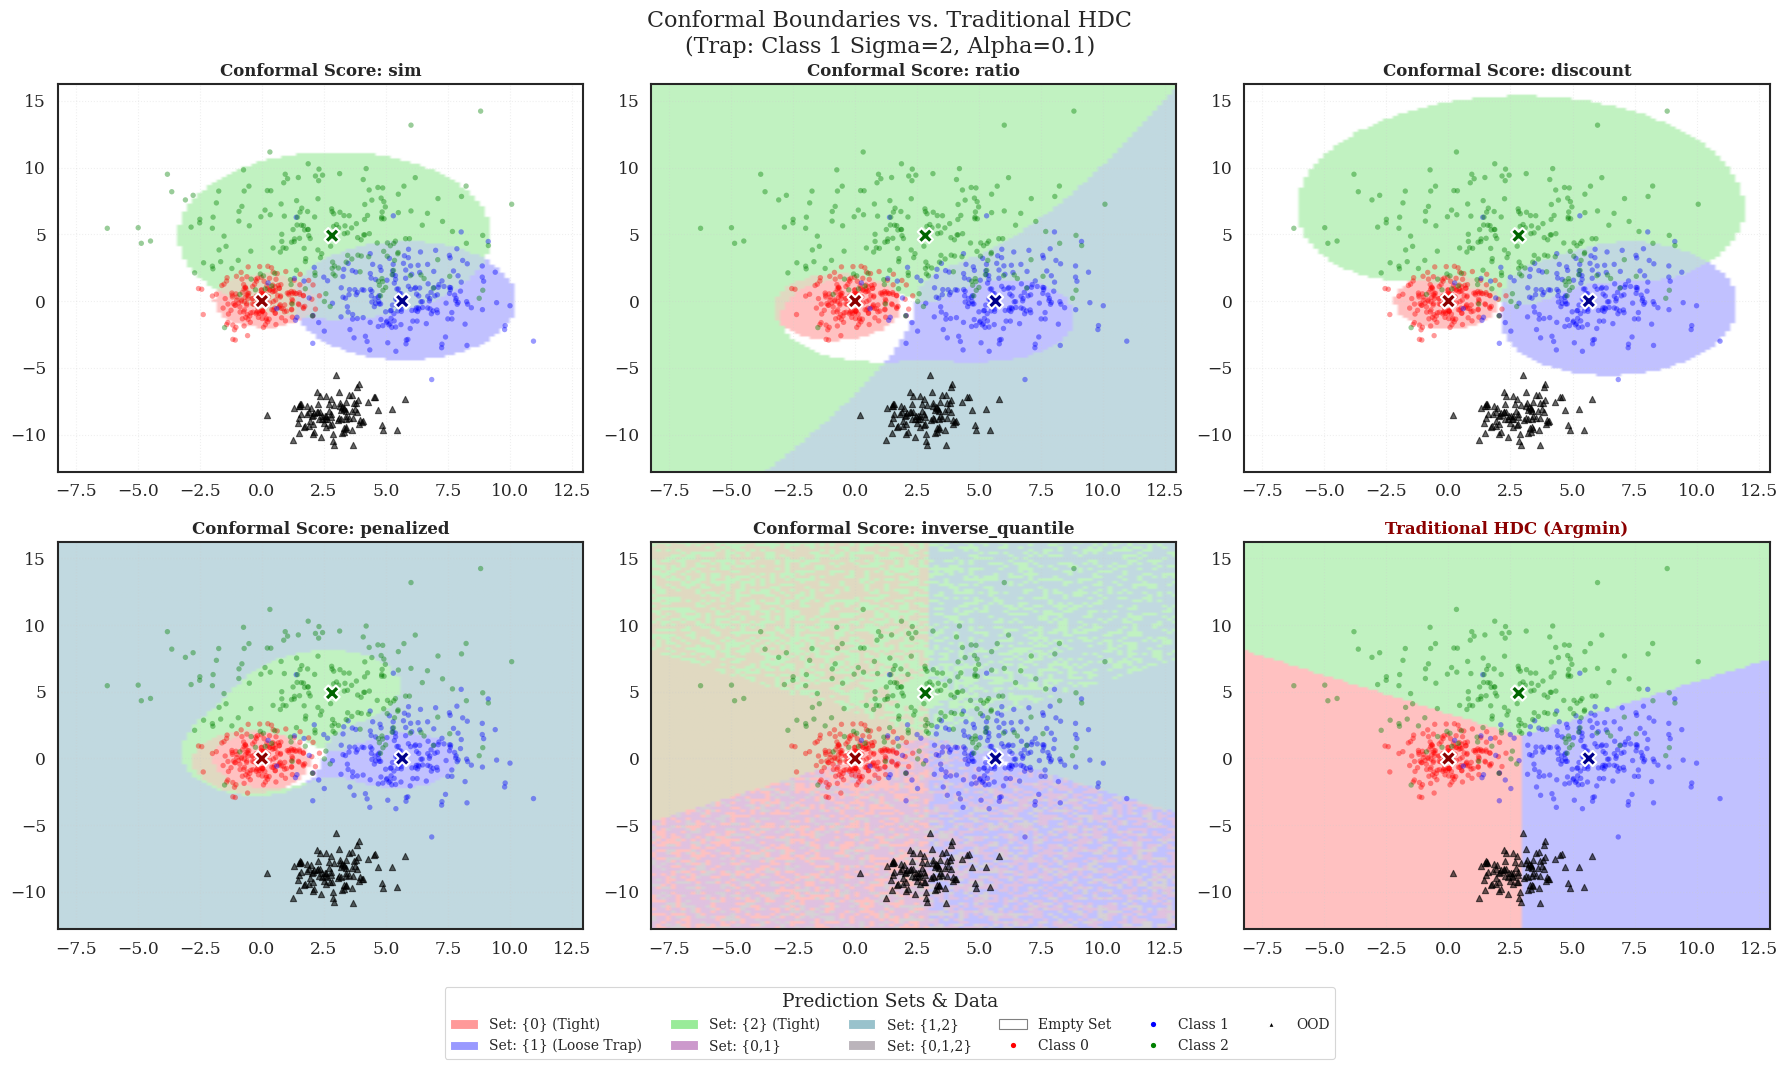

In [10]:
# ==========================================
# 1. GEOMETRY & DATA UTILS
# ==========================================
def setup_triangle_geometry(separation_factor, rng):
    dim = 2
    ref_sigma = 1.0
    r_ref = ref_sigma * np.sqrt(dim)
    dist = separation_factor * (r_ref + r_ref)

    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([dist, 0.0])
    mu2 = np.array([dist / 2, (np.sqrt(3) / 2) * dist])
    
    return np.stack([mu0, mu1, mu2]).astype(np.float32)

def generate_samples_3class(n_samples, prototypes, sigmas, rng):
    X_list = []
    y_list = []
    dim = prototypes.shape[1]
    
    for label, (mu, sigma) in enumerate(zip(prototypes, sigmas)):
        X_c = rng.randn(n_samples, dim) * sigma + mu
        X_list.append(X_c)
        y_list.append(np.full(n_samples, label))
        
    X = np.concatenate(X_list).astype(np.float32)
    y = np.concatenate(y_list).astype(int)
    return X, y

def generate_ood_blob(n_samples, prototypes, rng):
    center = np.mean(prototypes, axis=0)
    direction = np.array([0.0, -1.0]) 
    dist = np.linalg.norm(prototypes[2] - prototypes[0]) * 1.8
    mu_ood = center + direction * dist
    X_ood = rng.randn(n_samples, 2) * 1.0 + mu_ood 
    return X_ood.astype(np.float32)

from matplotlib.patches import Patch
# ==========================================
# 2. COLOR UTILS
# ==========================================
BASE_COLORS = {
    0: np.array([1.0, 0.0, 0.0]), # Red
    1: np.array([0.0, 0.0, 1.0]), # Blue
    2: np.array([0.0, 0.8, 0.0])  # Green
}

def get_region_color(pset):
    if len(pset) == 0:
        return np.array([1.0, 1.0, 1.0]) # White
    
    color_sum = np.zeros(3)
    for lbl in pset:
        color_sum += BASE_COLORS[lbl]
    
    avg_color = color_sum / len(pset)
    # Pastel-ize
    final_color = avg_color * 0.4 + np.array([1.0, 1.0, 1.0]) * 0.6
    return final_color

# ==========================================
# 3. EXPERIMENT CONFIG
# ==========================================
SEED = 42
rng = np.random.RandomState(SEED)

SCORE_TYPES = ["sim", "ratio", "discount", "penalized", "inverse_quantile"]
# Ensure we have exactly 5 scores to leave the 6th spot for Vanilla
if len(SCORE_TYPES) > 5: SCORE_TYPES = SCORE_TYPES[:5]

SAMPLES_PER_CLASS = 200
SEPARATION_CONST = 2.0 
SIGMAS = [1.0, 2, 3] 
ALPHA = 0.1
MARGINAL = False 

prototypes = setup_triangle_geometry(SEPARATION_CONST, rng)
X_cal, y_cal = generate_samples_3class(SAMPLES_PER_CLASS, prototypes, SIGMAS, rng)
X_test, y_test = generate_samples_3class(SAMPLES_PER_CLASS, prototypes, SIGMAS, rng)
X_ood = generate_ood_blob(100, prototypes, rng)

# Define Grid
x_min, x_max = np.min([X_test[:,0].min(), X_ood[:,0].min()]) - 2, np.max([X_test[:,0].max(), X_ood[:,0].max()]) + 2
y_min, y_max = np.min([X_test[:,1].min(), X_ood[:,1].min()]) - 2, np.max([X_test[:,1].max(), X_ood[:,1].max()]) + 2
resolution = 0.2

xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                     np.arange(y_min, y_max, resolution))
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# ==========================================
# 4. PLOTTING LOOP
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11)) # Increased height for legend
axes = axes.flatten()

chdc = ConformalHDC(class_HVs=prototypes, class_labels=[0, 1, 2],
                    sim_measure="euclidean", random_state=SEED)

# Helper to plot common elements (data points)
def plot_data_layer(ax):
    colors_map = ['red', 'blue', 'green']
    colors_test = [colors_map[c] for c in y_test]
    ax.scatter(X_test[:, 0], X_test[:, 1], c=colors_test, s=15, alpha=0.4, edgecolors='none')
    ax.scatter(X_ood[:, 0], X_ood[:, 1], c='black', marker='^', s=20, alpha=0.6)
    ax.scatter(prototypes[:, 0], prototypes[:, 1], c=['darkred', 'darkblue', 'darkgreen'], 
               marker='X', s=120, edgecolor='white', linewidth=1.5, zorder=5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.3)

# --- A. Plot 5 Conformal Variants ---
for idx, stype in enumerate(SCORE_TYPES):
    ax = axes[idx]
    
    # Calibrate & Predict
    chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
    psets = chdc.set_valued_CP(grid_points, ALPHA, marginal=MARGINAL)
    
    # Color Regions
    region_img = np.zeros((xx.shape[0], xx.shape[1], 3))
    for i, pset in enumerate(psets):
        r, c = divmod(i, xx.shape[1])
        region_img[r, c] = get_region_color(pset)
        
    ax.imshow(region_img, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.6, aspect='auto')
    plot_data_layer(ax)
    ax.set_title(f"Conformal Score: {stype}", fontsize=12, fontweight='bold')

# --- B. Plot 6: Vanilla HDC (Traditional) ---
ax_vanilla = axes[5]

# Vanilla Prediction: Argmin of distances (Hard classification)
# Calculate distances to prototypes for grid
dists = []
for p in prototypes:
    d = np.linalg.norm(grid_points - p, axis=1)
    dists.append(d)
dists = np.stack(dists, axis=1)
preds_vanilla = np.argmin(dists, axis=1)

# Color Regions (No uncertainty, just single classes)
region_img_v = np.zeros((xx.shape[0], xx.shape[1], 3))
for i, pred in enumerate(preds_vanilla):
    r, c = divmod(i, xx.shape[1])
    # Convert prediction to singleton set format for color util
    region_img_v[r, c] = get_region_color({pred})

ax_vanilla.imshow(region_img_v, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.6, aspect='auto')
plot_data_layer(ax_vanilla)
ax_vanilla.set_title("Traditional HDC (Argmin)", fontsize=12, fontweight='bold', color='darkred')

# ==========================================
# 5. BOTTOM LEGEND
# ==========================================
legend_patches = [
    # Singletons
    Patch(facecolor=get_region_color({0}), label='Set: {0} (Tight)'),
    Patch(facecolor=get_region_color({1}), label='Set: {1} (Loose Trap)'),
    Patch(facecolor=get_region_color({2}), label='Set: {2} (Tight)'),
    # Uncertainty
    Patch(facecolor=get_region_color({0,1}), label='Set: {0,1}'),
    Patch(facecolor=get_region_color({1,2}), label='Set: {1,2}'),
    Patch(facecolor=get_region_color({0,1,2}), label='Set: {0,1,2}'),
    # Empty
    Patch(facecolor=[1,1,1], edgecolor='gray', label='Empty Set'),
    # Points
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Class 0'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Class 1'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Class 2'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='black', label='OOD')
]

# Adjust layout to make room at bottom
plt.tight_layout(rect=[0, 0.1, 1, 0.95]) # Reserve bottom 10%

# Add legend to figure
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, 0.02),
           ncol=6, fontsize=10, title="Prediction Sets & Data", frameon=True)

plt.suptitle(f"Conformal Boundaries vs. Traditional HDC\n(Trap: Class 1 Sigma={SIGMAS[1]}, Alpha={ALPHA})", fontsize=16)
plt.show()

C:\Users\liang\AppData\Local\Temp\ipykernel_12372\358599554.py:99: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c=COLOR_MAP[frozenset([0])],
C:\Users\liang\AppData\Local\Temp\ipykernel_12372\358599554.py:102: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c=COLOR_MAP[frozenset([1])],
C:\Users\liang\AppData\Local\Temp

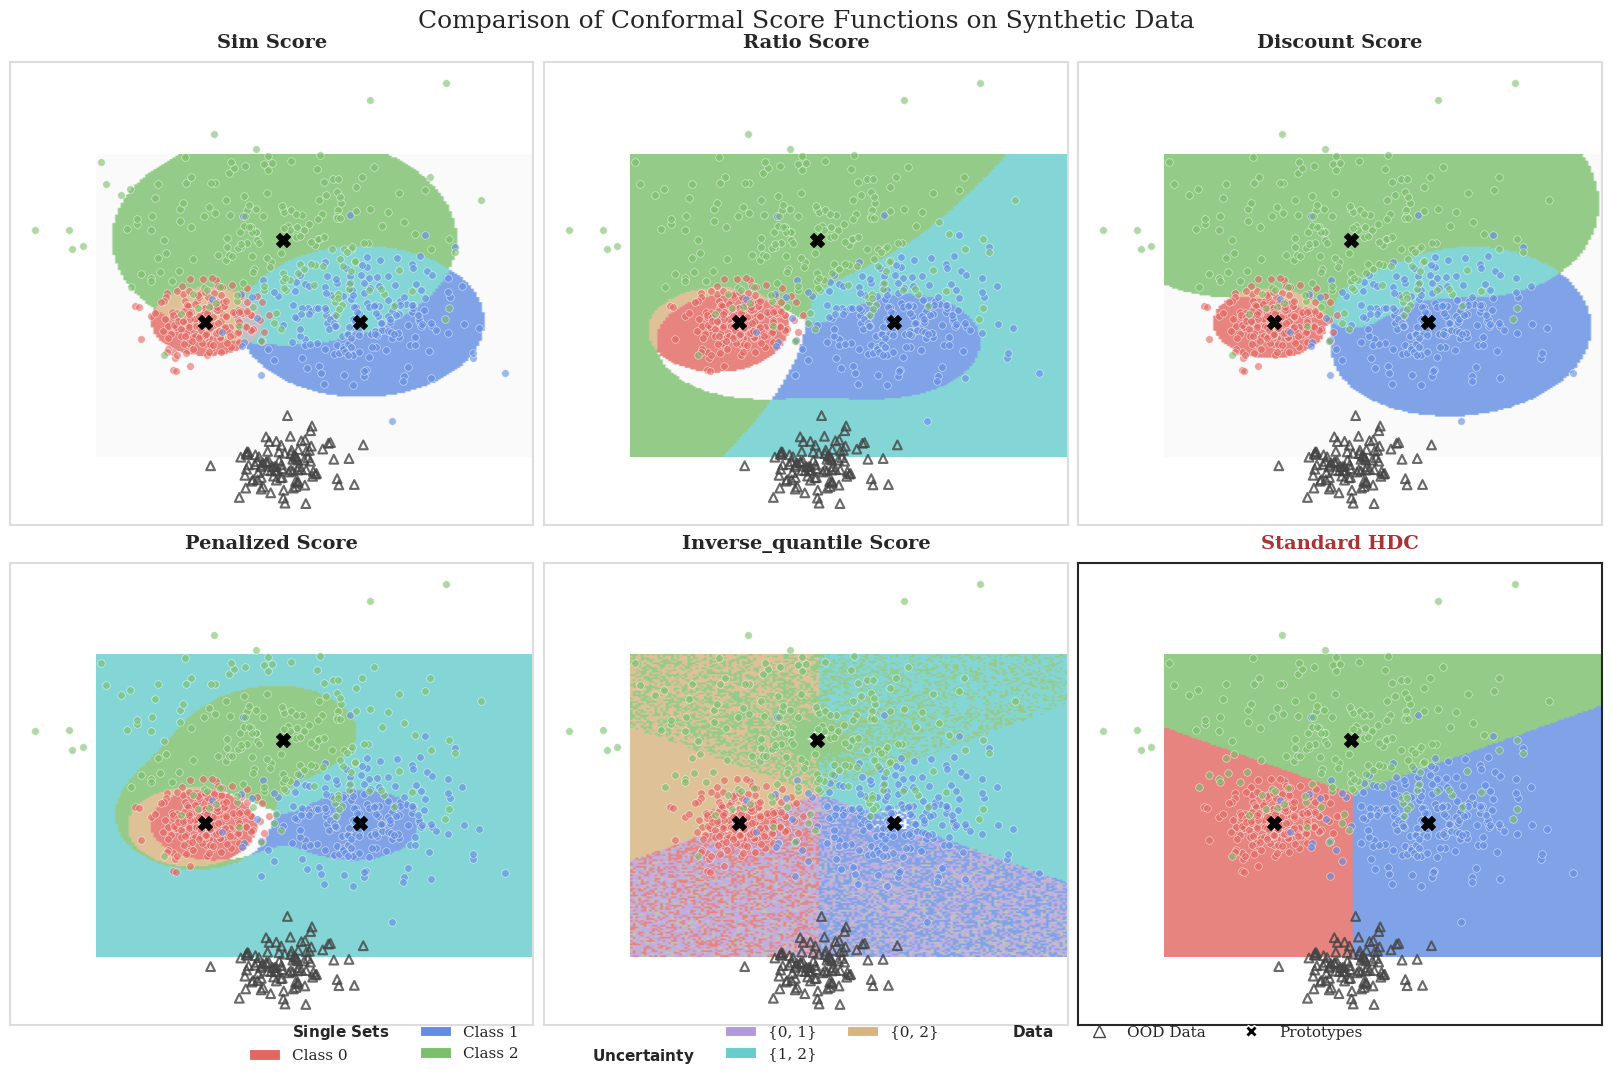

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# --- 1. Style Setup for "Paper" Look ---
sns.set_context("paper", font_scale=1.4)
sns.set_style("white")
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif' for modern look
plt.rcParams['axes.linewidth'] = 1.5

# --- 2. Sophisticated Color Palette (Lookup Table) ---
# We define specific colors for specific sets to avoid "muddy" averaging
# Format: frozenset(elements): (R, G, B)
# 0: Red-ish, 1: Blue-ish, 2: Green-ish
COLOR_MAP = {
    frozenset():            (0.98, 0.98, 0.98), # Empty: Near White
    frozenset([0]):         (0.89, 0.40, 0.38), # Soft Red
    frozenset([1]):         (0.38, 0.55, 0.89), # Soft Blue
    frozenset([2]):         (0.48, 0.75, 0.42), # Soft Green
    frozenset([0, 1]):      (0.70, 0.60, 0.85), # Purple (Overlap 0+1)
    frozenset([0, 2]):      (0.85, 0.70, 0.50), # Orange/Tan (Overlap 0+2)
    frozenset([1, 2]):      (0.40, 0.80, 0.80), # Teal (Overlap 1+2)
    frozenset([0, 1, 2]):   (0.70, 0.70, 0.70), # Gray (All classes)
}

def get_region_color_smart(pset):
    """Returns the specific designer color for a given set."""
    key = frozenset(pset)
    return COLOR_MAP.get(key, (0.9, 0.9, 0.9)) # Default gray if unknown

# --- 3. Data Generation (Kept from your script) ---
def setup_triangle_geometry(separation_factor, rng):
    dim = 2
    ref_sigma = 1.0
    r_ref = ref_sigma * np.sqrt(dim)
    dist = separation_factor * (r_ref + r_ref)
    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([dist, 0.0])
    mu2 = np.array([dist / 2, (np.sqrt(3) / 2) * dist])
    return np.stack([mu0, mu1, mu2]).astype(np.float32)

def generate_samples_3class(n_samples, prototypes, sigmas, rng):
    X_list = []
    y_list = []
    dim = prototypes.shape[1]
    for label, (mu, sigma) in enumerate(zip(prototypes, sigmas)):
        X_c = rng.randn(n_samples, dim) * sigma + mu
        X_list.append(X_c)
        y_list.append(np.full(n_samples, label))
    return np.concatenate(X_list).astype(np.float32), np.concatenate(y_list).astype(int)

def generate_ood_blob(n_samples, prototypes, rng):
    center = np.mean(prototypes, axis=0)
    direction = np.array([0.0, -1.0]) 
    dist = np.linalg.norm(prototypes[2] - prototypes[0]) * 1.8
    mu_ood = center + direction * dist
    return (rng.randn(n_samples, 2) * 1.0 + mu_ood).astype(np.float32)

# --- 4. Experiment Config ---
SEED = 42
rng = np.random.RandomState(SEED)
SCORE_TYPES = ["sim", "ratio", "discount", "penalized", "inverse_quantile"]
SIGMAS = [1.0, 2.0, 3.0] 
prototypes = setup_triangle_geometry(2.0, rng)
X_cal, y_cal = generate_samples_3class(200, prototypes, SIGMAS, rng)
X_test, y_test = generate_samples_3class(200, prototypes, SIGMAS, rng)
X_ood = generate_ood_blob(100, prototypes, rng)

# Grid setup (Higher resolution for smoother images)
resolution = 0.1 # Finer grain
x_min, x_max = -4, 12
y_min, y_max = -8, 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution), np.arange(y_min, y_max, resolution))
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# --- 5. Main Plotting Logic ---
# Using Constrained Layout for automatic nice spacing
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.flatten()

# Initialize Model (Assuming ConformalHDC class is available in your env)
try:
    chdc = ConformalHDC(class_HVs=prototypes, class_labels=[0, 1, 2],
                        sim_measure="euclidean", random_state=SEED)
except NameError:
    print("Error: ConformalHDC class not found. Make sure imports are correct.")
    # creating a dummy object for testing if you don't have the library loaded in this specific cell
    class MockHDC:
        def compute_calib_scores(self, x, y, score_type): pass
        def set_valued_CP(self, x, alpha, marginal): return [set([0]) for _ in x] # Dummy return
    chdc = MockHDC()

def plot_scatter(ax):
    """Helper to plot scatter points with 'halo' for visibility"""
    # Class 0
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c=COLOR_MAP[frozenset([0])], 
               s=30, alpha=0.6, edgecolors='white', linewidth=0.5, label='_nolegend_')
    # Class 1
    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c=COLOR_MAP[frozenset([1])], 
               s=30, alpha=0.6, edgecolors='white', linewidth=0.5, label='_nolegend_')
    # Class 2
    ax.scatter(X_test[y_test==2, 0], X_test[y_test==2, 1], c=COLOR_MAP[frozenset([2])], 
               s=30, alpha=0.6, edgecolors='white', linewidth=0.5, label='_nolegend_')
    # OOD
    ax.scatter(X_ood[:, 0], X_ood[:, 1], facecolors='none', edgecolors='#444444', 
               marker='^', s=40, linewidth=1.5, alpha=0.8, label='_nolegend_')
    # Prototypes
    ax.scatter(prototypes[:, 0], prototypes[:, 1], c='black', marker='X', s=100, zorder=10)

# Loop over scores
for idx, stype in enumerate(SCORE_TYPES):
    ax = axes[idx]
    
    # Run Conformal
    chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
    psets = chdc.set_valued_CP(grid_points, alpha=0.1, marginal=False)
    
    # Map sets to colors
    img_rgb = np.zeros((xx.shape[0], xx.shape[1], 3))
    for i, pset in enumerate(psets):
        r, c = divmod(i, xx.shape[1])
        img_rgb[r, c] = get_region_color_smart(pset)
        
    ax.imshow(img_rgb, extent=(x_min, x_max, y_min, y_max), origin='lower', aspect='auto', alpha=0.8)
    plot_scatter(ax)
    
    # Aesthetics
    ax.set_title(f"{stype.capitalize()} Score", fontsize=14, fontweight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_edgecolor('#DDDDDD')

# --- Plot Vanilla ---
ax_van = axes[5]
dists = np.stack([np.linalg.norm(grid_points - p, axis=1) for p in prototypes], axis=1)
preds = np.argmin(dists, axis=1)

img_van = np.zeros((xx.shape[0], xx.shape[1], 3))
for i, pred in enumerate(preds):
    r, c = divmod(i, xx.shape[1])
    img_van[r, c] = get_region_color_smart({pred})

ax_van.imshow(img_van, extent=(x_min, x_max, y_min, y_max), origin='lower', aspect='auto', alpha=0.8)
plot_scatter(ax_van)
ax_van.set_title("Standard HDC", fontsize=14, fontweight='bold', color='#AA3333', pad=10)
ax_van.set_xticks([])
ax_van.set_yticks([])

# --- Sophisticated Legend ---
# Create custom legend elements matching the COLOR_MAP
legend_elements = [
    # Header
    Line2D([0], [0], color='w', label=r'$\bf{Single\ Sets}$'),
    Patch(facecolor=COLOR_MAP[frozenset([0])], label='Class 0'),
    Patch(facecolor=COLOR_MAP[frozenset([1])], label='Class 1'),
    Patch(facecolor=COLOR_MAP[frozenset([2])], label='Class 2'),
    
    # Spacer
    Line2D([0], [0], color='w', label='   '), 

    # Uncertainty
    Line2D([0], [0], color='w', label=r'$\bf{Uncertainty}$'),
    Patch(facecolor=COLOR_MAP[frozenset([0,1])], label='{0, 1}'),
    Patch(facecolor=COLOR_MAP[frozenset([1,2])], label='{1, 2}'),
    Patch(facecolor=COLOR_MAP[frozenset([0,2])], label='{0, 2}'),
    
    # Other
    Line2D([0], [0], color='w', label='   '),
    Line2D([0], [0], color='w', label=r'$\bf{Data}$'),
    Line2D([0], [0], marker='^', color='w', markeredgecolor='#444444', markerfacecolor='none', markersize=8, label='OOD Data'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=8, label='Prototypes'),
]

# Place legend at bottom outside
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=8, frameon=False, fontsize=11)

plt.suptitle("Comparison of Conformal Score Functions on Synthetic Data", fontsize=18, y=1.02)
plt.show()